In [24]:
%load_ext autoreload
%autoreload 2

import platform
import pandas as pd
import os
import sys

system = platform.system()
if system == 'Linux':
    home = '/home/gerard/'
elif system == 'Darwin':
    home = '/Users/gerard/'
elif system == "Windows":
    home = 'C:/Users/cviko/'


try:
    sys.path.append(os.path.abspath(os.path.join(os.pardir, 'src')))
    from data_processing import *
    from utils import *
    from plotter import *
    from colocalization import *
except:
    path2add = home + 'analysis/confocal/src'
    sys.path.append(path2add)
    from data_processing import *
    from utils import *
    from plotter import *
    from colocalization import *

home = home + 'data/confocal/'



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
def df_separator(df):
    # 5x vs 1x
    keys = ['5x', '1x', '5x.alpha_', '5x.alphaprime_','5x.gamma_', '1x.alpha_', '1x.alphaprime_','1x.gamma_']
    dict_results = dict.fromkeys(keys) 
    for k in keys:
        ks = k.split('.')
        if len(ks) == 1:
            dict_results[k] = df[df['name'].str.contains(k, case=False, na=False)]
        else:
            dict_results[k] = df[
                            df['name'].str.contains(ks[0], case=False, na=False) &
                            df['name'].str.contains(ks[1], case=False, na=False)
                                                    ]
    return(dict_results)


In [ ]:

user = 'Carmina'
dates = [
    '2026_06_05',
    '2026_06_15', 
    '2026_06_25'
    ]

rows2drop = [
            [],
            [
                'dec02_5x_brain3gamma_R8', 
                'dec02_5x_brain4alpha_L16' 
            ],
            []
                ]



df_list = [] 
for i, date in enumerate(dates):
    path_csv = home + date + '_' + user + '/coloc_results.csv'
    df = pd.read_csv(path_csv)

    #TO EXCLUDE SOME ROWS:
    if rows2drop[i]:
        for name in rows2drop[i]:
   
            df = df.drop(df[df["name"] == name].index).reset_index(drop=True)
    ###########
    df_list.append(df)

pooled = (
    pd.concat(df_list, keys=dates, names=["date"])
    .reset_index(level="date")      # moves 'date' level out of the index into a column
    .reset_index(drop=True)         # replaces the remaining old-index level with plain 0..n
)
print(pooled.columns)
print(pooled['date'])
print(pooled['name'])






Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 'MB_total_fraction of HSP in Mito',
       'MB_total_fraction of Mito in HSP', 'MB_total_odds_ratio',
       'MB_total_enrichment', 'MB_syn_fraction of HSP in Mito',
       'MB_syn_fraction of Mito in HSP', 'MB_syn_odds_ratio',
       'MB_syn_enrichment', 'MB_non_syn_fraction of HSP in Mito',
       'MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 'snr_BRP', 'snr_HSP', 'snr_Mito',
       'snr_min_HSP_Mito'],
      dtype='str')
0     2026_06_05
1     2026_06_05
2     2026_06_05
3     2026_06_05
4     2026_06_05
5     2026_06_05
6     2026_06_05
7     2026_06_05
8     2026_06_05
9     2026_06_05
10    2026_06_15
11    2026_06_15
12    2026_06_15
13    2026_06_15
14    2026_06_15
15    2026_06_15
16    2026_06_15
17    2026_06_15
18    2026_06_15
19    2026_06_15
20    2026_06_25
2


===== df_list[0] — 5x vs 1x (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x
  W statistic = 0.8070
  p-value     = 0.0025
  → Significant deviation from normality

MB_non_syn_fraction of HSP in Mito_5x
  W statistic = 0.8183
  p-value     = 0.0037
  → Significant deviation from normality

MB_syn_fraction of HSP in Mito_1x
  W statistic = 0.9575
  p-value     = 0.7481
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_1x
  W statistic = 0.7058
  p-value     = 0.0010
  → Significant deviation from normality

Brown-Forsythe test
Statistic = 3.1850
p-value   = 0.0310
→ Variances differ significantly

Kruskal-Wallis test
H statistic = 9.9153
p-value     = 0.0193
→ Significant differences exist between groups

MB_syn_fraction of HSP in Mito_5x vs MB_non_syn_fraction of HSP in Mito_5x: p_adj = 0.6639 ns
MB_syn_fraction of HSP in Mito_5x vs MB_syn_fraction of HSP in Mito_1x: p_adj = 0.6639 ns
MB_syn_fraction of HSP in Mit

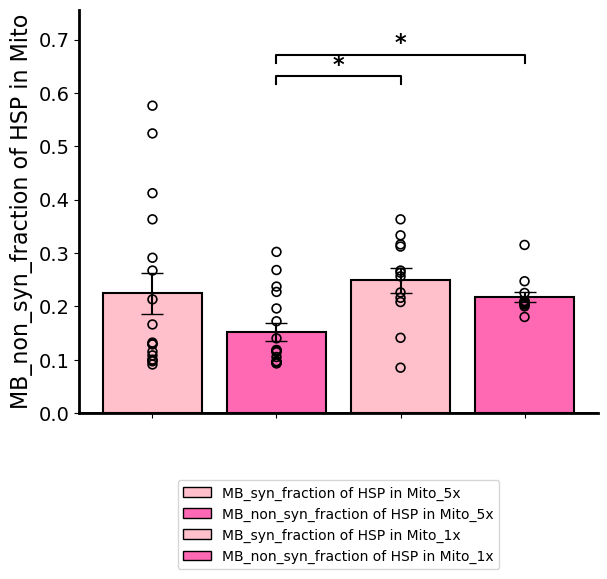


===== df_list[0] — 5x only (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x
  W statistic = 0.8070
  p-value     = 0.0025
  → Significant deviation from normality

MB_non_syn_fraction of HSP in Mito_5x
  W statistic = 0.8183
  p-value     = 0.0037
  → Significant deviation from normality

Brown-Forsythe test
Statistic = 3.0425
p-value   = 0.0907
→ Variances are not significantly different

Mann-Whitney U test
U statistic = 180.5000
p-value     = 0.2213
→ No significant difference detected

  Rank-biserial r = -0.2491
  Effect size: small

group: MB_syn_fraction of HSP in Mito_5x, mean: 0.2242352941176471, sem: 0.038110764402223676
group: MB_non_syn_fraction of HSP in Mito_5x, mean: 0.1521764705882353, sem: 0.016596029666520892


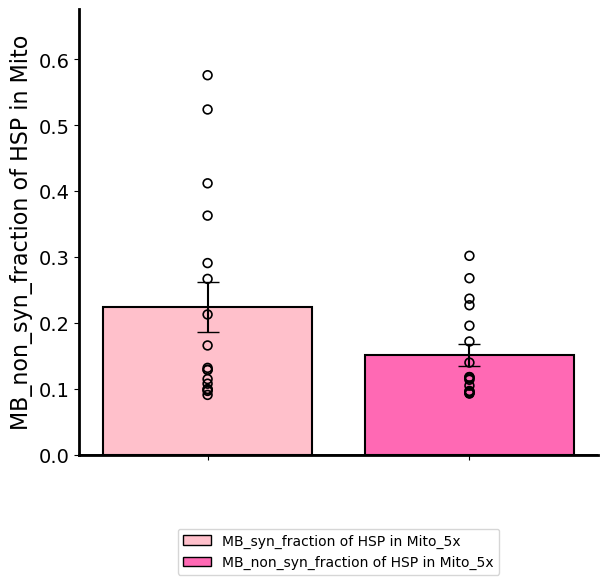


===== df_list[0] — 5x only by subregion =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x.alpha_
  W statistic = 0.7869
  p-value     = 0.0808
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.alpha_
  W statistic = 0.8228
  p-value     = 0.1497
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_5x.alphaprime_
  W statistic = 0.8531
  p-value     = 0.1667
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.alphaprime_
  W statistic = 0.8246
  p-value     = 0.0966
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.7116
  p-value     = 0.0050
  → Significant deviation from normality

MB_non_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.7182
  p-value     = 0.0058
  → Significant deviation from normality

Brown-Forsythe test
Statistic = 0.7385
p-value   = 0.6010
→ Variances are not significantly different

Kruskal-Wallis test
H statistic = 2.7653
p-value 

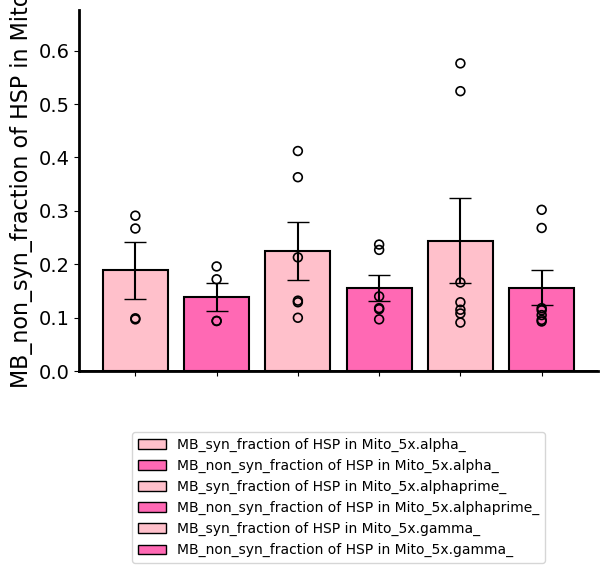

In [31]:

colmns2plot = ['MB_syn_fraction of HSP in Mito','MB_non_syn_fraction of HSP in Mito']
#colmns2plot = ['prop_MB-Mito_in_syn']
df_list = [
        #df_raw,
        #df_deconv,
        # df_deconv_blind2, 
        # df_deconv_blind4,
        pooled, 
        # df_deconv_blind20,
                
         ]
colors = [["pink","hotpink"],["skyblue","royalblue"],["lightgreen","seagreen"],["gold","darkorange"]]


# '5x'/'1x' are pooled totals; the six '.'-keys are per-subregion breakdowns of the
# SAME rows (e.g. '5x.alpha_' rows are a subset of '5x' rows). Mixing pooled and
# subregion groups in one fast_plotter call would run ANOVA/Tukey on non-independent
# groups, so each combination below is plotted separately.
plot_configs = [
   ("5x vs 1x (pooled, all regions combined)", ['5x', '1x']),
    #("5x vs 1x by subregion", ['5x.alpha_', '5x.alphaprime_', '5x.gamma_',
    #                            '1x.alpha_', '1x.alphaprime_', '1x.gamma_']),
    ("5x only (pooled, all regions combined)", ['5x']),
   # ("1x only (pooled, all regions combined)", ['1x']),
    ("5x only by subregion", ['5x.alpha_', '5x.alphaprime_', '5x.gamma_']),
    #("1x only by subregion", ['1x.alpha_', '1x.alphaprime_', '1x.gamma_']),
]

for j,df in enumerate(df_list):
    df_dict = df_separator(df)

    for title, key_group in plot_configs:
        col_data = {}
        new_col_list = []
        for k in key_group:
            df_k = df_dict[k]
            for col in colmns2plot:
                new_col = f"{col}_{k}"
                new_col_list.append(new_col)
                # reset_index: each key's rows keep their original df index (disjoint
                # across keys), so assigning straight into a DataFrame would align on
                # that index and turn every group but the first into all-NaN columns.
                col_data[new_col] = df_k[col].reset_index(drop=True)
        all_df = pd.concat(col_data, axis=1)

        print(f"\n===== df_list[{j}] — {title} =====")

        # one color per column-type in colmns2plot, repeated once per key in key_group
        # (works for any combination of len(colmns2plot)/len(key_group), unlike a
        # fixed /2 divisor which breaks when colmns2plot has an odd length or 1 entry)
        bar_color = colors[j][:len(colmns2plot)] * len(key_group)
        fast_plotter(new_col_list, df= all_df, ylabel=col,  bar_color=bar_color,  quietStats=False, figsize=(6,6), legend=True)
